In [1]:
# !pip install folium osmnx geopandas pandas shapely

import folium
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from datetime import datetime

In [2]:
### CONSTS ###
TRAFFIC_DIR = "../data/traffic"

LAT = 48.14553552490184
LNG = 17.114780288953938
MAP_ZOOM = 14
MAP_WIDTH = 2304
MAP_HEIGHT = 2304

START_TIME = datetime(2025, 1, 31, 6, 0)
END_TIME = datetime(2025, 1, 31, 9, 30)

# Load data into traffic graph

In [3]:
from city_graph import build_road_graph, visualize_graph

G_major, nodes_major, edges_major = build_road_graph("Bratislava, Slovakia")

m = visualize_graph(nodes_major, edges_major)
m

Processing 202 images



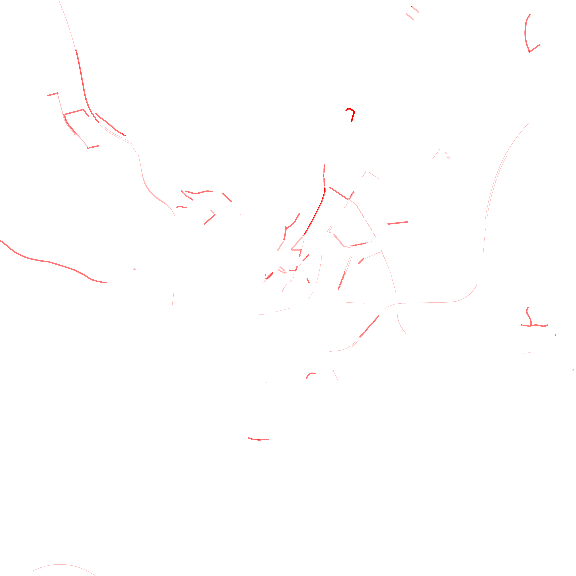

In [4]:
from traffic_data import build_traffic_raster, visualize_traffic_raster

aggregated_image = build_traffic_raster(
    folder=TRAFFIC_DIR, start_time=START_TIME, end_time=END_TIME, step=4
)

traffic_map = visualize_traffic_raster(
    raster=aggregated_image,
    center_lat=48.14553552490184,
    center_lng=17.114780288953938,
    zoom=14,
    width=2304,
    height=2304,
)
traffic_map

In [5]:
from traffic_graph import add_congestion_to_graph, visualize_weighted_graph


G_weighted = add_congestion_to_graph(
    graph=G_major,
    raster_image=aggregated_image,
    center_lat=LAT,
    center_lng=LNG,
    zoom=MAP_ZOOM,
)
print(G_weighted)

map_congestion = visualize_weighted_graph(G_weighted, center_lat=LAT, center_lng=LNG)
map_congestion

MultiDiGraph with 1961 nodes and 2935 edges


In [6]:
from vehicle_data import load_vehicle_positions, vehicle_heatmap

vehicles = load_vehicle_positions("../data/vehicles/merged_vehicles_piatok.csv", START_TIME, END_TIME)
vehicles.head()
         
m = vehicle_heatmap(vehicles, center_lat=LAT, center_lng=LNG)
m

In [7]:
from filter import crop_graph_radius

G_center = crop_graph_radius(
    G_weighted, center_lat=LAT, center_lng=LNG, radius_m=3000
)

map = visualize_weighted_graph(G_center, center_lat=48.1486, center_lng=17.1077)
map

# Deployments

In [8]:
from rsu.static_deployment import deploy_static_rsus
from rsu.visualize import visualize_rsu_deployment

NUM_RSUS = 100
COVERAGE_RADIUS = 300  # meters (urban DSRC approx)

rsu_nodes_static = deploy_static_rsus(
    graph=G_center, num_rsus=NUM_RSUS, coverage_radius_m=COVERAGE_RADIUS
)
print(rsu_nodes_static)

m = visualize_rsu_deployment(
    graph=G_center,
    rsu_nodes=rsu_nodes_static,
    center_lat=LAT,
    center_lng=LNG
)
m

[18386324, 2397024832, 248611207, 1401013462, 28838024, 1049702864, 2459453592, 591775990, 1553211, 26659813, 31231557, 27069352, 226150822, 270644257, 1169699379, 432603938, 32627159, 3438332273, 32626929, 752208008, 1120267859, 2544648, 4449811262, 46815463, 26683485, 2474347587, 259265530, 18047161, 176752560, 796693263, 311933084, 36665058, 31233466, 177065534, 2476686293, 5411787, 1717084962, 338796282, 338796278, 176752556, 9060144813, 26113793, 338796283, 344903921, 7342341, 1104452760, 1078521560, 176742997, 18005059, 2318839048, 1120244877, 2173108498, 1029433709, 28838480, 559624801, 27069332, 34825137, 26659814, 33764536, 59719240, 9060144808, 5410675, 55461869, 7342314, 518389465, 18386339, 286270126, 34471119, 3149903668, 31201194, 18004928, 5410659, 5410664, 25419627, 25531954, 26659764, 1241118694, 1599046888, 1241106619, 21451595, 176785672, 26856247, 36664704, 32591723, 2311112092, 29505177, 18395734, 26856249, 21451592, 32030105, 18395733, 33479973, 1903017545, 270653

In [9]:
from rsu.hybrid_deployment import deploy_hybrid_rsus

rsu_nodes_hybrid = deploy_hybrid_rsus(
    G_center, vehicles_df=vehicles, num_rsus=10, coverage_radius_m=300
)

m = visualize_rsu_deployment(
    graph=G_center, rsu_nodes=rsu_nodes_hybrid, center_lat=LAT, center_lng=LNG
)
m

KeyboardInterrupt: 

In [ ]:
from evaluation import build_comparison_table

deployments = {
    "static": rsu_nodes_static,
    # "topology": rsu_nodes_topology,
    # "hybrid": rsu_nodes_hybrid,
}

results = build_comparison_table(G_weighted, deployments, radius_m=300)

results

,num_rsus,node_coverage,road_coverage,avg_distance_to_rsu,redundancy,strategy
0,100,0.428353,0.375599,592.121546,0.138705,traffic
